In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\Sugavaneswara\Downloads\ecommerce_customer_satisfaction_200.csv")
print(df)

        Product Payment_Method Delivery_Type Customer_Satisfaction
0        Laptop    Credit Card      Standard             Satisfied
1    Smartphone     Debit Card      Standard               Neutral
2        Tablet    Credit Card      Standard               Neutral
3    Smartwatch     Debit Card      Standard               Neutral
4    Headphones    Credit Card      Standard             Satisfied
..          ...            ...           ...                   ...
195      Laptop    Net Banking      Standard               Neutral
196  Smartphone            UPI      Standard             Satisfied
197      Tablet    Net Banking      Standard               Neutral
198  Smartwatch     Debit Card      Standard               Neutral
199  Headphones    Credit Card      Standard               Neutral

[200 rows x 4 columns]


In [7]:
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

df["Product"] = le1.fit_transform(df["Product"])
df["Payment_Method"] = le2.fit_transform(df["Payment_Method"])
df["Delivery_Type"] = le3.fit_transform(df["Delivery_Type"])

print(df)

     Product  Payment_Method  Delivery_Type Customer_Satisfaction
0          1               0              2             Satisfied
1          2               1              2               Neutral
2          4               0              2               Neutral
3          3               1              2               Neutral
4          0               0              2             Satisfied
..       ...             ...            ...                   ...
195        1               2              2               Neutral
196        2               3              2             Satisfied
197        4               2              2               Neutral
198        3               1              2               Neutral
199        0               0              2               Neutral

[200 rows x 4 columns]


In [8]:
X = df[["Product", "Payment_Method", "Delivery_Type"]]
y = df["Customer_Satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = BernoulliNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Satisfied")
recall = recall_score(y_test, y_pred, pos_label="Satisfied")
f1 = f1_score(y_test, y_pred, pos_label="Satisfied")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.675
Precision: 0.675
Recall: 1.0
F1 Score: 0.8059701492537313


Confusion Matrix:
[[ 0 13]
 [ 0 27]]


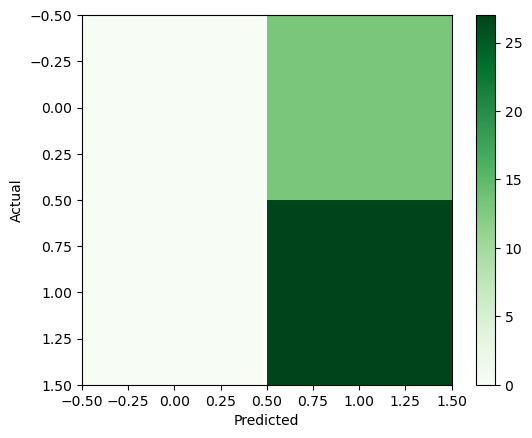

In [11]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

plt.imshow(cm, cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()